# GWAS Overlap and Correlation Alignment Analysis

This notebook examines the enrichment of Schizophrenia GWAS genes in glia modules and tests whether the correlation shifts (ΔZ) between cell types align with the GWAS enrichment (Odds Ratio) of the modules.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import scanpy as sc

# Add sources directory to path
sys.path.append(os.path.abspath('../../sources'))

import gwas_utils as gu
import wgcna_utils as wu
import corr_utils as cu

/data/home/swkim0523/.local/lib/python3.9/site-packages/setuptools_scm/version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


In [2]:
# Parameters
data_dir = '../../data/primary_cohort'
wgcna_dir = os.path.join(data_dir, 'WGCNA_modules')
pb_filtered_dir = os.path.join(data_dir, 'pb_ct_filtered')
gwas_path = '../../data/gwas-association-downloaded_2026-03-23-MONDO_0005090.tsv'

z_summary_thres = 2
n_perm = 10000

## 1. Load Data and Modules

In [3]:
# Load GWAS genes
gwas_genes = gu.load_gwas_genes(gwas_path)
print(f"Total GWAS genes: {len(gwas_genes)}")

# Load modules
mic_modules, mic_bg = wu.get_module_dict(
    'microglia', 
    os.path.join(wgcna_dir, 'df_zsummary_microglia.csv'), 
    os.path.join(wgcna_dir, 'modules_whole_microglia.csv'), 
    z_summary_thres=z_summary_thres
)

ast_modules, ast_bg = wu.get_module_dict(
    'astrocyte', 
    os.path.join(wgcna_dir, 'df_zsummary_astrocyte.csv'), 
    os.path.join(wgcna_dir, 'modules_whole_astrocyte.csv'), 
    z_summary_thres=z_summary_thres
)

print(f"Microglia modules: {len(mic_modules)}, Background genes: {len(mic_bg)}")
print(f"Astrocyte modules: {len(ast_modules)}, Background genes: {len(ast_bg)}")

Total GWAS genes: 2025
Module 1: 369 genes
Module 2: 1586 genes
Module 3: 1257 genes
Module 4: 59 genes
Module 5: 66 genes
Module 6: 58 genes
Module 8: 424 genes
Module 9: 221 genes
Module 10: 104 genes
Module 11: 109 genes
Module 12: 92 genes
Module 13: 131 genes
Module 14: 326 genes
Module 15: 249 genes
Module 16: 403 genes
Module 17: 91 genes
Module 18: 154 genes
Module 19: 207 genes
Module 20: 4342 genes
Module 21: 630 genes
Module 1: 474 genes
Module 2: 2888 genes
Module 3: 992 genes
Module 4: 195 genes
Module 5: 74 genes
Module 7: 618 genes
Module 8: 284 genes
Module 9: 126 genes
Module 10: 165 genes
Module 11: 104 genes
Module 12: 103 genes
Module 13: 322 genes
Module 14: 180 genes
Module 15: 363 genes
Module 16: 593 genes
Module 17: 247 genes
Module 18: 251 genes
Module 19: 3575 genes
Module 20: 723 genes
Microglia modules: 20, Background genes: 11722
Astrocyte modules: 19, Background genes: 12882


## 2. GWAS Enrichment Analysis

In [4]:
# Calculate enrichment
print("=======Mic======")
mic_gwas_fisher = gu.calculate_gwas_enrichment(mic_modules, gwas_genes, mic_bg)

print("=======Ast======")
ast_gwas_fisher = gu.calculate_gwas_enrichment(ast_modules, gwas_genes, ast_bg)

# Prepare OR series with prefixes for alignment
mic_or_series = mic_gwas_fisher.set_index('Module')['OddsRatio']
mic_or_series.index = [f"Mic{i}" for i in mic_or_series.index]

ast_or_series = ast_gwas_fisher.set_index('Module')['OddsRatio']
ast_or_series.index = [f"Ast{i}" for i in ast_or_series.index]

print("Microglia GWAS Enrichment (Top modules by OR):")
display(mic_gwas_fisher.sort_values('OddsRatio', ascending=False))

print("Astrocyte GWAS Enrichment (Top modules by OR):")
display(ast_gwas_fisher.sort_values('OddsRatio', ascending=False))

=======Mic======
1 22 347 901 9608
2 242 1344 681 8611
3 109 1148 814 8807
4 1 58 922 9897
5 3 63 920 9892
6 1 57 922 9898
8 25 399 898 9556
9 22 199 901 9756
10 12 92 911 9863
11 5 104 918 9851
12 8 84 915 9871
13 9 122 914 9833
14 28 298 895 9657
15 21 228 902 9727
16 24 379 899 9576
17 4 87 919 9868
18 7 147 916 9808
19 17 190 906 9765
20 322 4020 601 5935
21 41 589 882 9366
=======Ast======
1 23 451 959 10844
2 231 2657 751 8638
3 56 936 926 10359
4 18 177 964 11118
5 9 65 973 11230
7 58 560 924 10735
8 38 246 944 11049
9 12 114 970 11181
10 13 152 969 11143
11 12 92 970 11203
12 3 100 979 11195
13 16 306 966 10989
14 11 169 971 11126
15 26 337 956 10958
16 45 548 937 10747
17 19 228 963 11067
18 19 232 963 11063
19 269 3306 713 7989
20 104 619 878 10676
Microglia GWAS Enrichment (Top modules by OR):


,Module,Module_Gene_Count,GWAS_Overlap_Count,Overlap_Ratio,OddsRatio,P_value,P_adj
1,2,1586,242,0.152585,2.276788,2.175330e-22,4.350659e-21
8,10,104,12,0.115385,1.412161,1.701132e-01,9.995480e-01
7,9,221,22,0.099548,1.197062,2.456750e-01,9.995480e-01
10,12,92,8,0.086957,1.027426,5.252540e-01,9.995480e-01
2,3,1257,109,0.086714,1.027279,4.170814e-01,9.995480e-01
12,14,326,28,0.085890,1.013820,5.024494e-01,9.995480e-01
13,15,249,21,0.084337,0.993246,5.454955e-01,9.995480e-01
17,19,207,17,0.082126,0.964360,5.933596e-01,9.995480e-01
11,13,131,9,0.068702,0.793638,7.915457e-01,9.995480e-01
18,20,4342,322,0.074159,0.790999,9.995480e-01,9.995480e-01


Astrocyte GWAS Enrichment (Top modules by OR):


,Module,Module_Gene_Count,GWAS_Overlap_Count,Overlap_Ratio,OddsRatio,P_value,P_adj
18,20,723,104,0.143845,2.042945,1.626667e-09,3.090668e-08
6,8,284,38,0.133803,1.808004,1.152647e-03,1.095014e-02
4,5,74,9,0.121622,1.598071,1.350071e-01,5.130268e-01
9,11,104,12,0.115385,1.506455,1.262303e-01,5.130268e-01
7,9,126,12,0.095238,1.213348,3.069924e-01,8.332650e-01
5,7,618,58,0.093851,1.203289,1.113770e-01,5.130268e-01
3,4,195,18,0.092308,1.172867,2.970341e-01,8.332650e-01
1,2,2888,231,0.079986,0.999985,5.133980e-01,9.988031e-01
8,10,165,13,0.078788,0.983509,5.647654e-01,9.988031e-01
15,17,247,19,0.076923,0.957684,6.057295e-01,9.988031e-01


## 3. Calculate ΔZ Matrix

In [5]:
# Load pseudobulk and calculate eigengenes (as in notebook 3)
ast_control = sc.read_h5ad(os.path.join(pb_filtered_dir, 'pb_astrocyte_control_filtered.h5ad'))
ast_scz     = sc.read_h5ad(os.path.join(pb_filtered_dir, 'pb_astrocyte_scz_filtered.h5ad'))
mic_control = sc.read_h5ad(os.path.join(pb_filtered_dir, 'pb_microglia_control_filtered.h5ad'))
mic_scz     = sc.read_h5ad(os.path.join(pb_filtered_dir, 'pb_microglia_scz_filtered.h5ad'))

# Rename modules with prefixes for matrix
mic_modules_pre = {f"Mic{k}": v for k, v in mic_modules.items()}
ast_modules_pre = {f"Ast{k}": v for k, v in ast_modules.items()}

ast_c_eigen = cu.get_module_eigen_expression(ast_control, ast_modules_pre)
ast_s_eigen = cu.get_module_eigen_expression(ast_scz, ast_modules_pre)
mic_c_eigen = cu.get_module_eigen_expression(mic_control, mic_modules_pre)
mic_s_eigen = cu.get_module_eigen_expression(mic_scz, mic_modules_pre)

r_c = cu.get_cross_corr(mic_c_eigen, ast_c_eigen)
r_s = cu.get_cross_corr(mic_s_eigen, ast_s_eigen)

delta_z, _ = cu.calculate_delta_corr_significance(r_s, mic_scz.n_obs, r_c, mic_control.n_obs)

print(f"ΔZ matrix shape: {delta_z.shape} (Rows: Microglia, Cols: Astrocyte)")

ΔZ matrix shape: (20, 19) (Rows: Microglia, Cols: Astrocyte)


## 4. Alignment: Astrocyte modules vs. Microglia GWAS OR

For each Astrocyte module, we correlate its ΔZ values (across all Microglia modules) with the GWAS Odds Ratio of the corresponding Microglia modules.

Permutation: 100%|██████████| 10000/10000 [05:46<00:00, 28.90it/s]


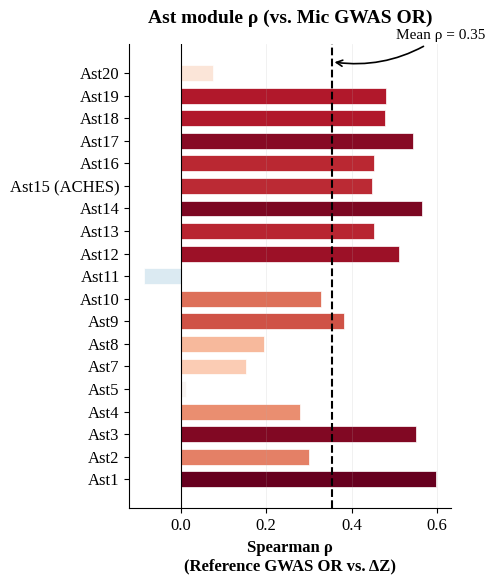

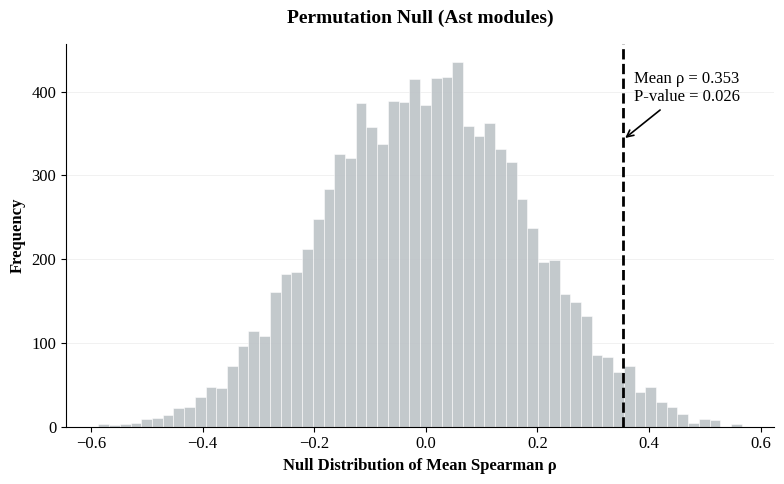

In [8]:
# Rows of delta_z are Microglia, columns are Astrocyte.
# We want to correlate each Astrocyte module (column) with mic_or_series (which aligns with rows).
t_obs_ast, t_null_ast, pval_ast = gu.run_permutation_test(mic_or_series, delta_z.T, n_perm=n_perm)

rho_series_ast, p_series_ast = gu.calculate_rho_series(mic_or_series, delta_z.T)

rho_series_ast = rho_series_ast.rename({"Ast15":"Ast15 (ACHES)"})

gu.plot_gwas_rho_barplot(
    rho_series_ast, t_obs_ast, 
    title="Ast module ρ (vs. Mic GWAS OR)",
    save_path="../../figures/fig4b_ast_rho_barplot"
)

gu.plot_permutation_null(
    t_null_ast, t_obs_ast, pval_ast, 
    title="Permutation Null (Ast modules)",
    save_path="../../figures/fig4d_ast_permutation_null"
)

## 5. Alignment: Microglia modules vs. Astrocyte GWAS OR

Similarly, for each Microglia module, we correlate its ΔZ values (across all Astrocyte modules) with the GWAS Odds Ratio of the corresponding Astrocyte modules.

Permutation: 100%|██████████| 10000/10000 [05:58<00:00, 27.91it/s]


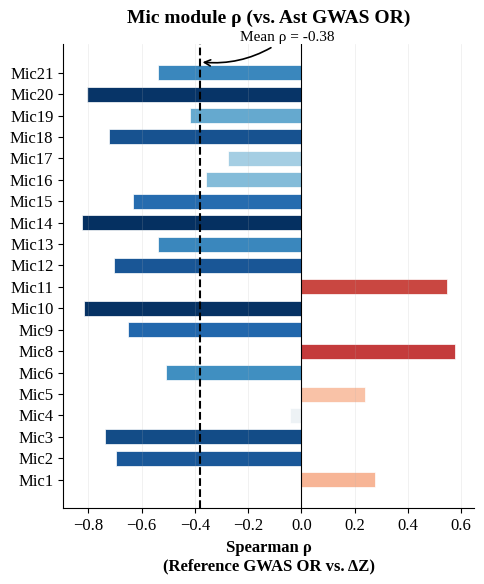

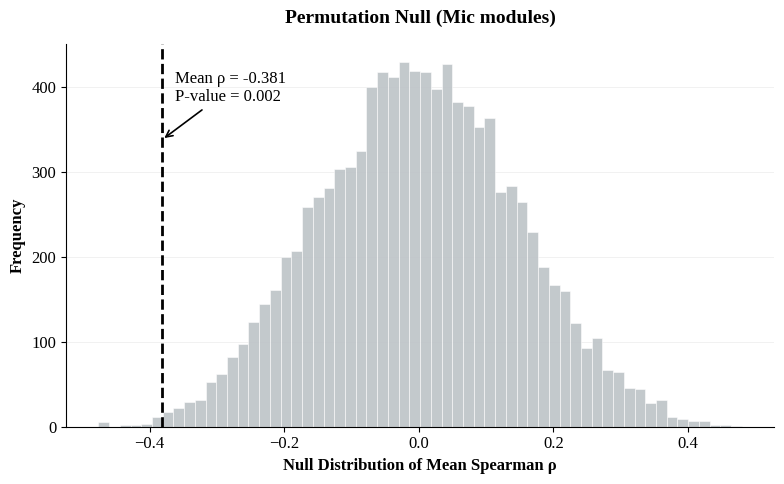

In [9]:
# Rows of delta_z are Microglia. 
# We want to correlate each Microglia module (row) with ast_or_series (which aligns with columns).
t_obs_mic, t_null_mic, pval_mic = gu.run_permutation_test(ast_or_series, delta_z, n_perm=n_perm, alternative='less')

rho_series_mic, p_series_mic = gu.calculate_rho_series(ast_or_series, delta_z)

gu.plot_gwas_rho_barplot(
    rho_series_mic, t_obs_mic, 
    title="Mic module ρ (vs. Ast GWAS OR)",
    save_path="../../figures/fig4c_mic_rho_barplot"
)

gu.plot_permutation_null(
    t_null_mic, t_obs_mic, pval_mic, 
    title="Permutation Null (Mic modules)",
    save_path="../../figures/fig4e_mic_permutation_null"
)

In [10]:
def vis_and_calc_spearmann_OR(target_module):
    from scipy.stats import spearmanr, norm
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # 1. 현재 노트북의 데이터 구조에 맞게 데이터 추출
    # delta_z는 (Mic x Ast) 형태이므로 target_module이 컬럼에 있는지 확인
    if target_module in delta_z.columns:
        dz_series = delta_z[target_module]
        # 필요하다면 Fisher Z로 변환된 상관계수 값들도 가져옵니다.
        # r_c, r_s는 이미 피어슨 상관계수 행렬입니다.
        from corr_utils import fisher_z
        z_ctrl_series = fisher_z(r_c[target_module])
        z_scz_series = fisher_z(r_s[target_module])
    else:
        dz_series = delta_z.loc[target_module]
        from corr_utils import fisher_z
        z_ctrl_series = fisher_z(r_c.loc[target_module])
        z_scz_series = fisher_z(r_s.loc[target_module])

    # 2. 통계치 계산 (기존 로직 유지)
    # 현재 데이터셋의 샘플 수(n_obs)를 사용하거나 요청하신 대로 97, 94를 사용합니다.
    # n_scz = mic_scz.n_obs; n_ctrl = mic_control.n_obs
    se = np.sqrt(1/(97-3) + 1/(94-3))
    z_scores_sig = dz_series / se
    p_values_sig = 2 * (1 - norm.cdf(abs(z_scores_sig)))

    df_1 = pd.DataFrame({
        "Z_ctrl"  : z_ctrl_series,
        "Z_scz"   : z_scz_series,
        "Z_diff"  : dz_series, # Scatter plot에 사용될 raw delta Z
        "p_value" : p_values_sig
    })

    # 3. GWAS 결과(mic_gwas_fisher)와 병합
    df_gwas = mic_gwas_fisher.copy()
    df_gwas['Module_name'] = 'Mic' + df_gwas['Module'].astype(str)
    
    # 인덱스를 맞춰서 Join
    merged = df_gwas.set_index('Module_name').join(df_1[['Z_diff']], how='inner')

    # 4. Spearman 상관관계 계산
    corr, pval = spearmanr(merged['OddsRatio'], merged['Z_diff'])
    print(f"Target Module: {target_module}")
    print(f"Spearman correlation: {corr:.4f}")
    print(f"p-value: {pval:.4e}")
    print(f"분석에 사용된 모듈 수: {len(merged)}")

    # 5. 시각화 (스타일 똑같이 재현)
    fig, ax = plt.subplots(figsize=(6, 5))

    # Scatter plot
    ax.scatter(merged['OddsRatio'], merged['Z_diff'],
               color='purple', edgecolors='white', s=40, alpha=0.8, linewidths=0.5, zorder=3)

    # Annotate (모듈 이름 표시)
    for idx, row in merged.iterrows():
        ax.annotate(idx,
                    xy=(row['OddsRatio'], row['Z_diff']),
                    xytext=(-1, 4), textcoords='offset points',
                    fontsize=8, color='black')

    # Trend line (polyfit)
    x = merged['OddsRatio']
    y = merged['Z_diff']
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, p(x_line), color='#F577A7', linewidth=1.5, linestyle='--', label='Trend line')

    # Spearman 결과 텍스트 박스
    ax.text(0.75, 0.1, f'Spearman r = {corr:.3f}\np = {pval:.2e}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    # Label 및 Grid 설정
    ax.set_xlabel('GWAS Gene Odds Ratio (Microglia Modules, Fisher Exact Test)', fontweight='bold', fontsize=12)
    if target_module == 'Ast15':
        target_module = 'Ast15 (ACHES)'
    ax.set_ylabel(f'ΔZ to {target_module}', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    
    # 파일 저장 (요청하신 파일명 유지)
    fig.savefig(f"../../figures/fig4a_new_{target_module.lower()}.svg", dpi=300, bbox_inches="tight")
    fig.savefig(f"../../figures/fig4a_new_{target_module.lower()}.png", dpi=300, bbox_inches="tight", pad_inches=0.08)

    plt.show()

    return [corr, pval]



Target Module: Ast15
Spearman correlation: 0.4466
p-value: 4.8373e-02
분석에 사용된 모듈 수: 20


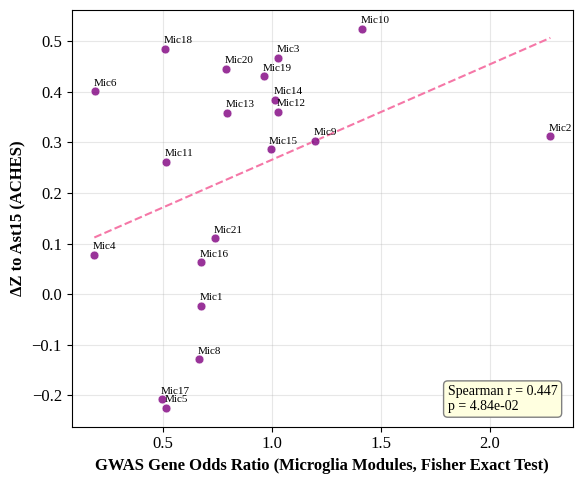

In [11]:
rho, p = vis_and_calc_spearmann_OR('Ast15')


In [1]:
import scipy.stats as stats

In [6]:
stats.binomtest(16, n=20, p=0.5, alternative='greater')

BinomTestResult(k=16, n=20, alternative='greater', statistic=0.8, pvalue=0.005908966064453125)